# Karachi Air Quality (PM2.5) - Feature Selection & Target Correlation Analysis
**Notebook**: `notebooks/feature_selection.ipynb`  
**Dataset**: `data/processed/karachi_features.csv`  
**Target Variable**: `target_pm25` (Next-Hour PM2.5 Concentration, $t+1$)

---

### Objectives
1. **Linear Correlation Analysis (Pearson $r$)**: Quantify linear correlation between all 37 engineered features and `target_pm25`.
2. **Monotonic Non-Linear Correlation (Spearman $\rho$)**: Assess monotonic dependencies robust against outliers and distribution skewness.
3. **Autoregressive & Lag Persistence**: Examine PM2.5 temporal autocorrelation and lag decay curves (24h, 48h, 72h, 168h).
4. **Mutual Information (MI)**: Measure non-linear information gain using entropy-based mutual information regression.
5. **Collinearity & VIF Analysis**: Detect inter-feature collinearity ($|r| > 0.80$) and compute Variance Inflation Factor (VIF).
6. **Tree-Based Feature Importance**: Fit Random Forest & Extra Trees Regressors to compute Mean Decrease in Impurity (MDI) importance.
7. **Comprehensive Feature Selection Ranking**: Consolidate statistical, non-linear, and ensemble scores into a composite ranking to select the optimal feature subset for model training.

## 1. Imports and Environment Setup

In [2]:
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature selection & statistical metrics
from scipy import stats
from sklearn.feature_selection import (
    mutual_info_regression,
    f_regression,
    SelectKBest
)
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Plot formatting
%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Load Processed Feature Dataset
We load `karachi_features.csv` (which contains 38 total columns: 37 candidate predictors + 1 target column `target_pm25`).

In [3]:
# Determine data file location
DATA_PATH = Path("../data/processed/karachi_features.csv") if Path("../data/processed/karachi_features.csv").exists() else Path("data/processed/karachi_features.csv")
print(f"Loading data from: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH, parse_dates=["datetime"])

print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"Date Coverage: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Total Missing Values: {df.isnull().sum().sum()}")
df.head()

Loading data from: E:\Career\Internships\10 Pearls - Data Science Internship\data\processed\karachi_features.csv
Total Rows: 17,135
Total Columns: 38
Date Coverage: 2024-09-01 00:00:00+00:00 to 2026-08-15 22:00:00+00:00
Total Missing Values: 0


,datetime,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,PM2.5,PM10,NO2,SO2,CO,O3,year,month,day,hour,weekday,is_weekend,pm25_lag_24,pm25_lag_48,pm25_lag_72,pm25_lag_168,pm25_roll_mean_24,pm25_roll_std_24,pm25_roll_mean_72,pm25_roll_std_72,temp_humidity,wind_pm25,hour_sin,hour_cos,month_sin,month_cos,target_pm25
0,2024-09-01 00:00:00+00:00,25.4,95,24.5,29.4,0.0,0.0,1004.0,31,15.7,99,9.3,21.1,8.7,7.5,145.0,22.0,2024,9,1,0,6,1,12.3,10.3,8.6,22.6,11.520833,1.504191,13.754167,3.751542,2413.0,146.01,0.000000,1.000000,-1.0,-1.836970e-16,9.4
1,2024-09-01 01:00:00+00:00,25.5,95,24.7,29.7,0.0,0.0,1003.8,41,15.5,94,9.4,21.7,9.6,8.9,168.0,22.0,2024,9,1,1,6,1,11.8,9.7,8.8,22.9,11.420833,1.563435,13.762500,3.741034,2422.5,145.70,0.258819,0.965926,-1.0,-1.836970e-16,10.5
2,2024-09-01 02:00:00+00:00,25.9,94,24.8,29.9,0.0,0.0,1004.2,32,17.6,101,10.5,24.2,10.9,10.9,198.0,22.0,2024,9,1,2,6,1,11.9,7.9,10.3,23.1,11.362500,1.570880,13.765278,3.738500,2434.6,184.80,0.500000,0.866025,-1.0,-1.836970e-16,10.9
3,2024-09-01 03:00:00+00:00,26.8,88,24.7,30.2,0.1,0.1,1004.6,57,21.3,106,10.9,28.5,11.3,12.4,217.0,25.0,2024,9,1,3,6,1,12.3,6.9,12.9,23.6,11.304167,1.560513,13.737500,3.752424,2358.4,232.17,0.707107,0.707107,-1.0,-1.836970e-16,11.8
4,2024-09-01 04:00:00+00:00,27.7,82,24.2,30.5,0.3,0.3,1005.0,72,23.3,112,11.8,33.3,10.2,13.2,211.0,33.0,2024,9,1,4,6,1,10.7,7.5,13.3,23.9,11.350000,1.558148,13.716667,3.759045,2271.4,274.94,0.866025,0.500000,-1.0,-1.836970e-16,12.3


## 3. Define Predictors ($X$) and Target ($y$)
We index by `datetime` and separate the target variable `target_pm25` from predictor features.

In [4]:
# Index by datetime
df_indexed = df.set_index("datetime")

TARGET = "target_pm25"
y = df_indexed[TARGET]
X = df_indexed.drop(columns=[TARGET])

print(f"Target Column: '{TARGET}' (Shape: {y.shape})")
print(f"Total Candidate Features: {X.shape[1]}")
print(f"Feature Names:\n{list(X.columns)}")

Target Column: 'target_pm25' (Shape: (17135,))
Total Candidate Features: 36
Feature Names:
['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'year', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'pm25_lag_24', 'pm25_lag_48', 'pm25_lag_72', 'pm25_lag_168', 'pm25_roll_mean_24', 'pm25_roll_std_24', 'pm25_roll_mean_72', 'pm25_roll_std_72', 'temp_humidity', 'wind_pm25', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


## 4. Pearson Linear Correlation with Target Variable
The Pearson correlation coefficient ($r$) measures the linear association between each feature and `target_pm25`.

In [5]:
# Compute Pearson correlation with target_pm25
pearson_series = df_indexed.corr(method="pearson")[TARGET].drop(TARGET)

pearson_df = pd.DataFrame({
    "Feature": pearson_series.index,
    "Pearson_r": pearson_series.values,
    "Abs_Pearson_r": pearson_series.abs().values
}).sort_values(by="Abs_Pearson_r", ascending=False).reset_index(drop=True)

print("Top 15 Features by Absolute Pearson Correlation with target_pm25:")
display(pearson_df.head(15))

Top 15 Features by Absolute Pearson Correlation with target_pm25:


,Feature,Pearson_r,Abs_Pearson_r
0,PM2.5,0.961836,0.961836
1,pm25_roll_mean_24,0.739707,0.739707
2,pm25_roll_mean_72,0.615995,0.615995
3,pm25_lag_24,0.604368,0.604368
4,CO,0.558938,0.558938
5,NO2,0.533199,0.533199
6,PM10,0.510889,0.510889
7,pm25_roll_std_24,0.509914,0.509914
8,SO2,0.495768,0.495768
9,pm25_roll_std_72,0.487928,0.487928


### Visualizing Pearson Correlation Coefficients
- **Positive Correlation (Blue)**: Pollutants (`PM2.5`, `CO`, `NO2`, `PM10`, `SO2`), lag/rolling features, and surface pressure.
- **Negative Correlation (Red)**: Dispersion/weather factors (`temperature_2m`, `apparent_temperature`, `temp_humidity`, `wind_speed_10m`, `relative_humidity_2m`).

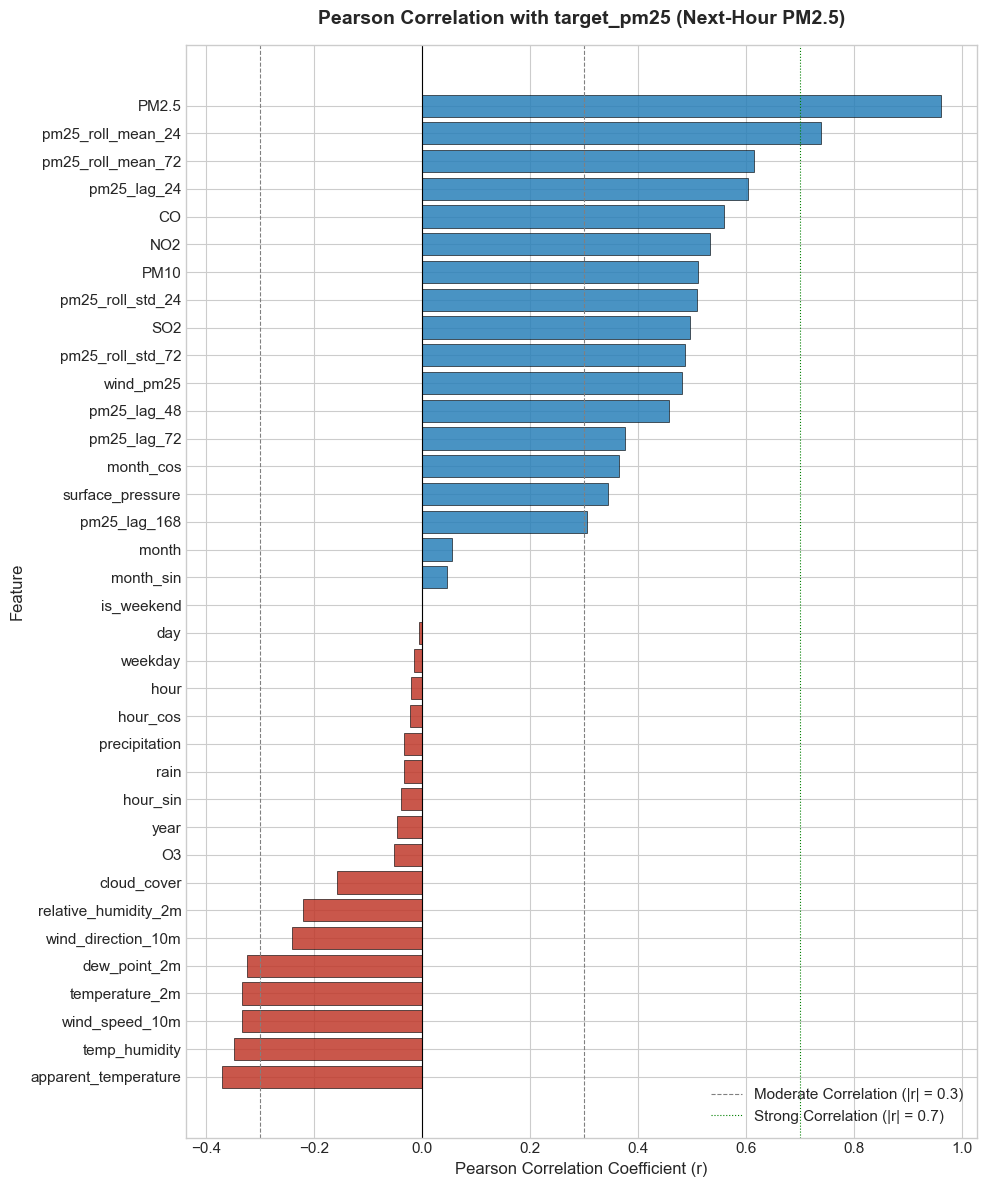

In [6]:
plt.figure(figsize=(10, 12))
sorted_pearson = pearson_df.sort_values(by="Pearson_r", ascending=True)
colors = ["#2980b9" if val >= 0 else "#c0392b" for val in sorted_pearson["Pearson_r"]]

plt.barh(sorted_pearson["Feature"], sorted_pearson["Pearson_r"], color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
plt.axvline(0, color="black", linestyle="-", linewidth=0.8)
plt.axvline(0.3, color="gray", linestyle="--", linewidth=0.8, label="Moderate Correlation (|r| = 0.3)")
plt.axvline(-0.3, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0.7, color="green", linestyle=":", linewidth=0.8, label="Strong Correlation (|r| = 0.7)")

plt.title("Pearson Correlation with target_pm25 (Next-Hour PM2.5)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Pearson Correlation Coefficient (r)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Spearman Rank Correlation (Monotonic Relationships)
Spearman correlation ($
ho$) assesses monotonic relationships without assuming linear proportionality, making it robust against non-linear scaling and heavy-tailed pollution spikes.

In [7]:
# Compute Spearman rank correlation with target_pm25
spearman_series = df_indexed.corr(method="spearman")[TARGET].drop(TARGET)

spearman_df = pd.DataFrame({
    "Feature": spearman_series.index,
    "Spearman_rho": spearman_series.values,
    "Abs_Spearman_rho": spearman_series.abs().values
}).sort_values(by="Abs_Spearman_rho", ascending=False).reset_index(drop=True)

# Merge Pearson and Spearman comparisons
corr_comp_df = pd.merge(
    pearson_df[["Feature", "Pearson_r", "Abs_Pearson_r"]],
    spearman_df[["Feature", "Spearman_rho", "Abs_Spearman_rho"]],
    on="Feature"
)
corr_comp_df["Rank_Diff"] = np.abs(
    corr_comp_df["Abs_Pearson_r"].rank(ascending=False) - 
    corr_comp_df["Abs_Spearman_rho"].rank(ascending=False)
)

print("Top 15 Features by Spearman Rank Correlation with target_pm25:")
display(corr_comp_df.sort_values(by="Abs_Spearman_rho", ascending=False).head(15))

Top 15 Features by Spearman Rank Correlation with target_pm25:


,Feature,Pearson_r,Abs_Pearson_r,Spearman_rho,Abs_Spearman_rho,Rank_Diff
0,PM2.5,0.961836,0.961836,0.963624,0.963624,0.0
1,pm25_roll_mean_24,0.739707,0.739707,0.748068,0.748068,0.0
3,pm25_lag_24,0.604368,0.604368,0.627397,0.627397,1.0
2,pm25_roll_mean_72,0.615995,0.615995,0.625357,0.625357,1.0
6,PM10,0.510889,0.510889,0.591809,0.591809,2.0
4,CO,0.558938,0.558938,0.529941,0.529941,1.0
7,pm25_roll_std_24,0.509914,0.509914,0.516340,0.516340,1.0
8,SO2,0.495768,0.495768,0.501535,0.501535,1.0
11,pm25_lag_48,0.457705,0.457705,0.469705,0.469705,3.0
9,pm25_roll_std_72,0.487928,0.487928,0.461631,0.461631,0.0


### Pearson vs. Spearman Comparison

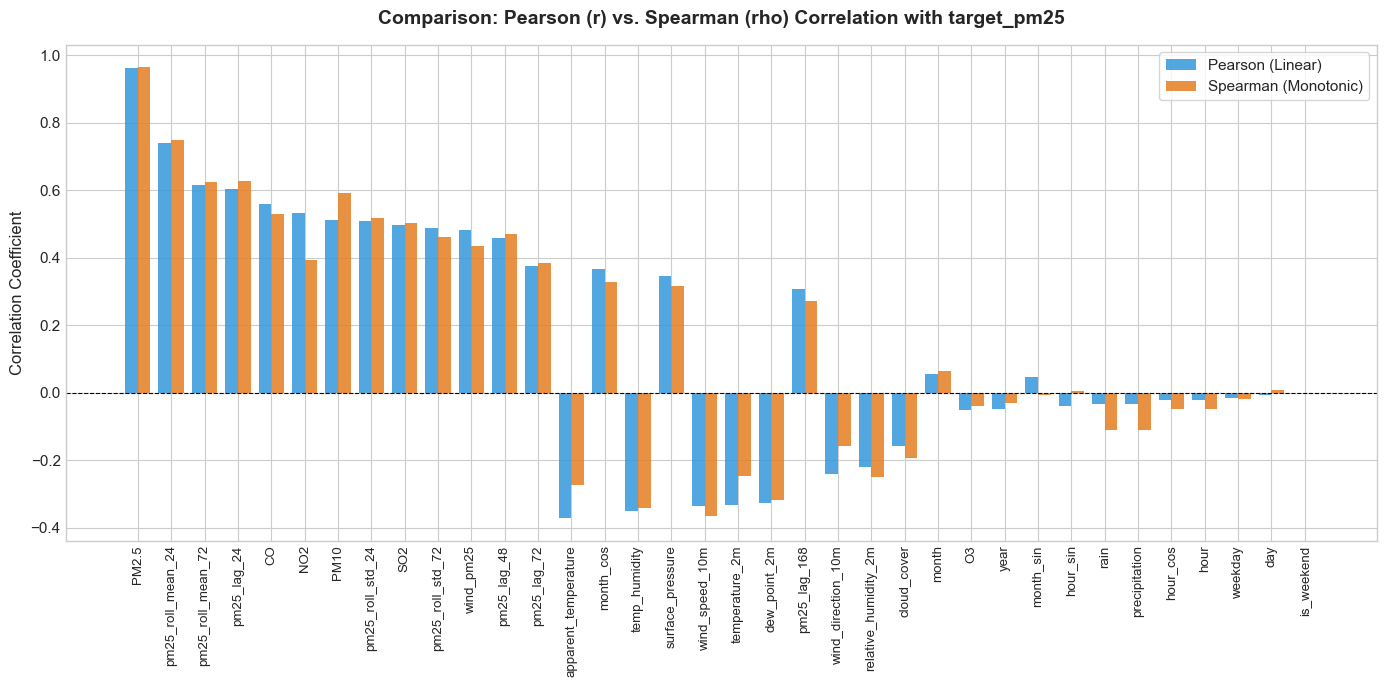

In [8]:
# Side-by-side comparison plot of Pearson vs Spearman
fig, ax = plt.subplots(figsize=(14, 7))
indices = np.arange(len(corr_comp_df))
bar_width = 0.38

sorted_comp = corr_comp_df.sort_values("Abs_Pearson_r", ascending=False)

ax.bar(indices - bar_width/2, sorted_comp["Pearson_r"], bar_width, label="Pearson (Linear)", color="#3498db", alpha=0.85)
ax.bar(indices + bar_width/2, sorted_comp["Spearman_rho"], bar_width, label="Spearman (Monotonic)", color="#e67e22", alpha=0.85)

ax.set_xticks(indices)
ax.set_xticklabels(sorted_comp["Feature"], rotation=90, fontsize=9.5)
ax.set_ylabel("Correlation Coefficient", fontsize=12)
ax.set_title("Comparison: Pearson (r) vs. Spearman (rho) Correlation with target_pm25", fontsize=14, fontweight="bold", pad=15)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

## 6. Autoregressive & Temporal Lag Persistence
PM2.5 displays strong temporal persistence. We evaluate autocorrelation across historical lags (24h, 48h, 72h, 168h) and rolling window aggregations.

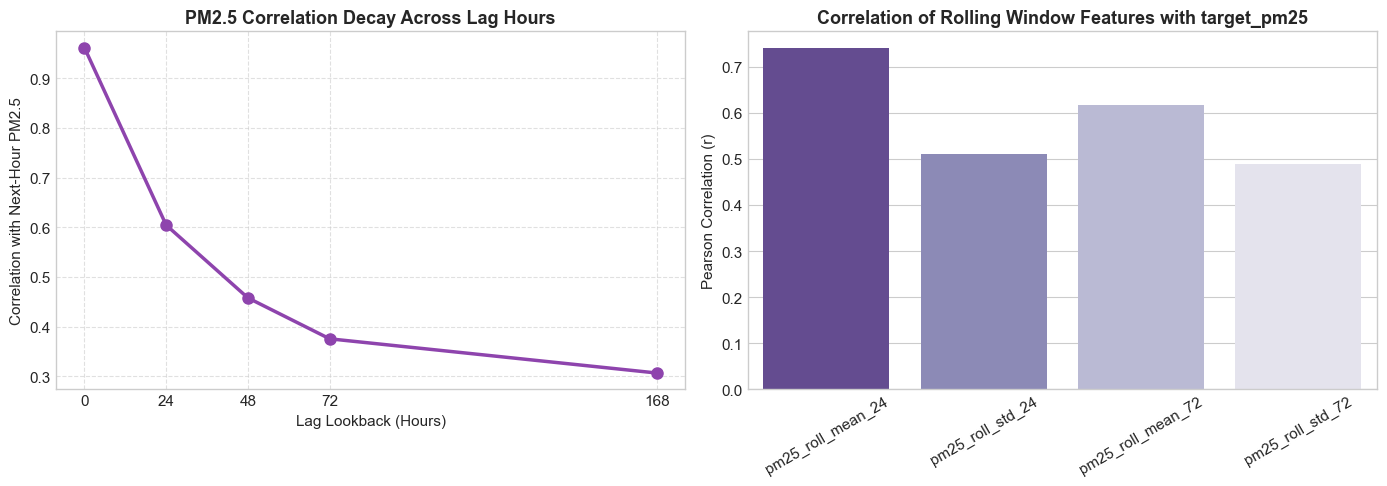

In [9]:
lag_features = ["PM2.5", "pm25_lag_24", "pm25_lag_48", "pm25_lag_72", "pm25_lag_168"]
lag_hours = [0, 24, 48, 72, 168]
lag_corrs = [pearson_series[f] for f in lag_features]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Lag decay curve
ax1.plot(lag_hours, lag_corrs, marker="o", color="#8e44ad", linewidth=2.5, markersize=8)
ax1.set_title("PM2.5 Correlation Decay Across Lag Hours", fontweight="bold")
ax1.set_xlabel("Lag Lookback (Hours)")
ax1.set_ylabel("Correlation with Next-Hour PM2.5")
ax1.set_xticks(lag_hours)
ax1.grid(True, linestyle="--", alpha=0.6)

# Rolling features comparison
roll_features = ["pm25_roll_mean_24", "pm25_roll_std_24", "pm25_roll_mean_72", "pm25_roll_std_72"]
roll_corrs = [pearson_series[f] for f in roll_features]
sns.barplot(x=roll_features, y=roll_corrs, ax=ax2, palette="Purples_r")
ax2.set_title("Correlation of Rolling Window Features with target_pm25", fontweight="bold")
ax2.set_ylabel("Pearson Correlation (r)")
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 7. Mutual Information (Non-Linear Dependency)
Shannon's Mutual Information (MI) quantifies the amount of shared information between each predictor and `target_pm25`, capturing non-linear relationships that Pearson correlation may overlook.

In [10]:
# Compute Mutual Information Regression
print("Computing Mutual Information regression scores (Shannon Information)...")
mi_values = mutual_info_regression(X, y, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI_Score": mi_values
}).sort_values(by="MI_Score", ascending=False).reset_index(drop=True)

print("Top 15 Features by Mutual Information:")
display(mi_df.head(15))

Computing Mutual Information regression scores (Shannon Information)...
Top 15 Features by Mutual Information:


,Feature,MI_Score
0,PM2.5,1.510506
1,pm25_roll_mean_24,0.487733
2,PM10,0.428384
3,pm25_roll_mean_72,0.335004
4,pm25_lag_24,0.286121
5,pm25_roll_std_72,0.265250
6,pm25_roll_std_24,0.238759
7,CO,0.200689
8,SO2,0.192552
9,wind_pm25,0.168493


### Mutual Information Score Ranking

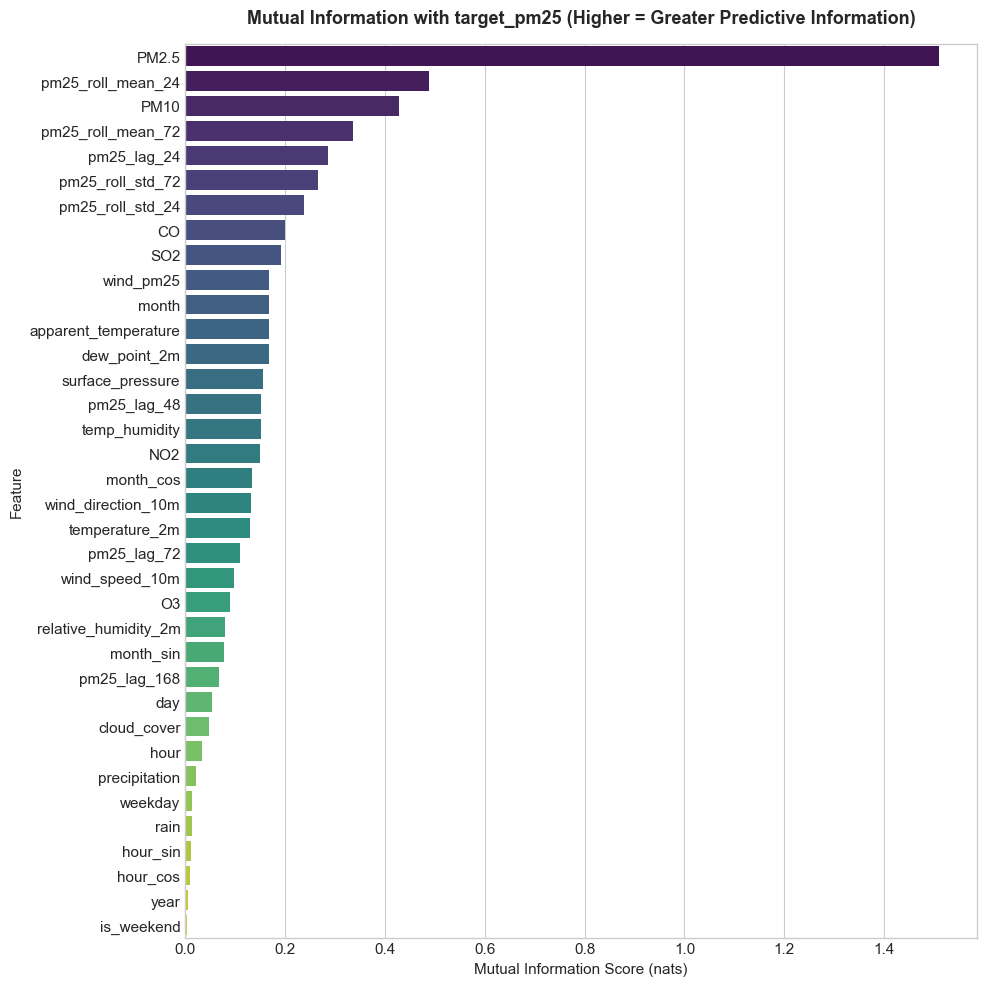

In [11]:
plt.figure(figsize=(10, 10))
sns.barplot(
    data=mi_df,
    y="Feature",
    x="MI_Score",
    palette="viridis"
)
plt.title("Mutual Information with target_pm25 (Higher = Greater Predictive Information)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Mutual Information Score (nats)", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.tight_layout()
plt.show()

## 8. Inter-Feature Correlation & Collinearity Heatmap
High pairwise correlation among predictors ($|r| > 0.80$) signals redundancy and potential multicollinearity.

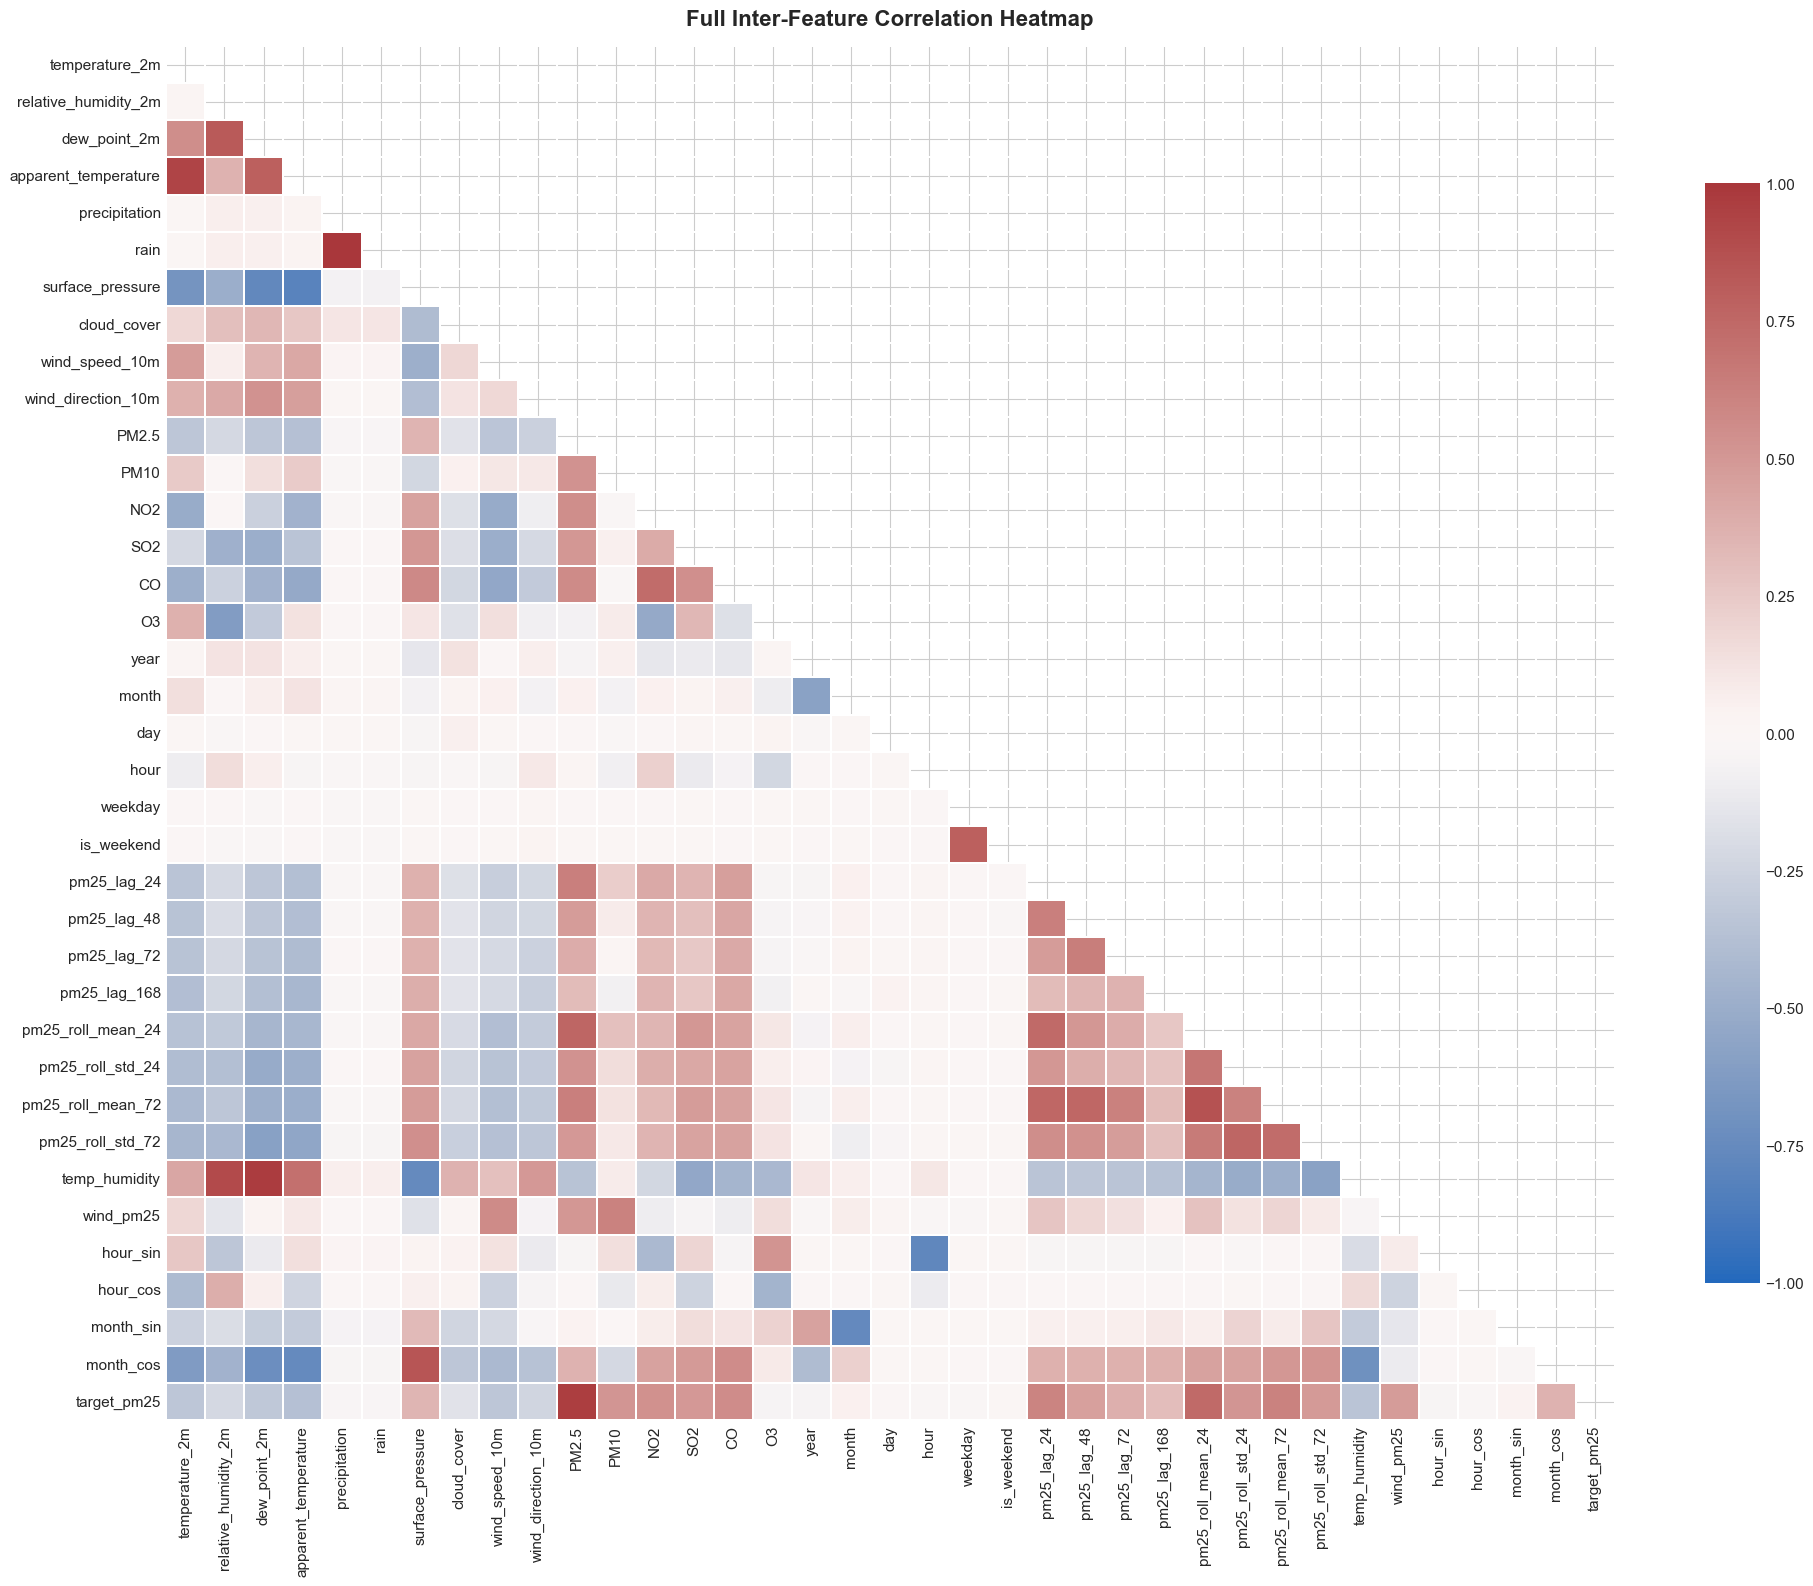

In [12]:
# Full correlation matrix
full_corr = df_indexed.corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(full_corr, dtype=bool))
sns.heatmap(
    full_corr,
    mask=mask,
    cmap="vlag",
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=False,
    cbar_kws={"shrink": 0.8},
    linewidths=0.3
)
plt.title("Full Inter-Feature Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### High Collinearity Feature Pairs ($|r| > 0.80$)

In [13]:
# Detect feature pairs with |r| > 0.80
X_corr = X.corr().abs()
upper_matrix = X_corr.where(np.triu(np.ones(X_corr.shape), k=1).astype(bool))

collinear_pairs = []
for col in upper_matrix.columns:
    for idx in upper_matrix.index:
        val = upper_matrix.loc[idx, col]
        if pd.notnull(val) and val > 0.80:
            collinear_pairs.append({
                "Feature 1": idx,
                "Feature 2": col,
                "Correlation": round(val, 4)
            })

collinear_df = pd.DataFrame(collinear_pairs).sort_values(by="Correlation", ascending=False).reset_index(drop=True)
print(f"Total High Collinearity Pairs (|r| > 0.80): {len(collinear_df)}")
display(collinear_df)

Total High Collinearity Pairs (|r| > 0.80): 8


,Feature 1,Feature 2,Correlation
0,precipitation,rain,1.0000
1,dew_point_2m,temp_humidity,0.9715
2,temperature_2m,apparent_temperature,0.9330
3,relative_humidity_2m,temp_humidity,0.9002
4,pm25_roll_mean_24,pm25_roll_mean_72,0.8604
5,surface_pressure,month_cos,0.8476
6,relative_humidity_2m,dew_point_2m,0.8249
7,apparent_temperature,surface_pressure,0.8066


## 9. Variance Inflation Factor (VIF) Analysis
VIF assesses the degree of multicollinearity among predictors ($VIF_i = \frac{1}{1 - R_i^2}$). While tree models handle collinearity well, linear and regularized models require pruning or regularization when $\text{VIF} > 10$.

In [14]:
# Compute VIF on standardized predictors using Linear Regression R^2
def compute_vif_dataframe(df_features):
    vif_list = []
    features = list(df_features.columns)
    for col in features:
        X_other = df_features.drop(columns=[col])
        y_col = df_features[col]
        reg = LinearRegression().fit(X_other, y_col)
        r2 = reg.score(X_other, y_col)
        vif = 1.0 / (1.0 - r2) if r2 < 0.99999 else 10000.0
        vif_list.append({
            "Feature": col,
            "R_Squared": round(r2, 4),
            "VIF": round(vif, 2)
        })
    return pd.DataFrame(vif_list).sort_values(by="VIF", ascending=False).reset_index(drop=True)

scaler = StandardScaler()
X_scaled_df = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

vif_df = compute_vif_dataframe(X_scaled_df)

print("Variance Inflation Factor (VIF) Table:")
display(vif_df)

Variance Inflation Factor (VIF) Table:


,Feature,R_Squared,VIF
0,rain,1.0000,10000.00
1,precipitation,1.0000,10000.00
2,apparent_temperature,0.9964,279.29
3,temperature_2m,0.9940,166.16
4,temp_humidity,0.9930,143.29
5,relative_humidity_2m,0.9824,56.91
6,dew_point_2m,0.9765,42.61
7,pm25_roll_mean_72,0.9247,13.28
8,PM2.5,0.9202,12.53
9,wind_pm25,0.9118,11.33


## 10. Tree-Based Feature Importance (Random Forest & Extra Trees)
Tree ensembles evaluate multivariate non-linear interactions and feature splits simultaneously.

In [15]:
print("Fitting Random Forest & Extra Trees regressors for feature ranking...")

rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

et_model = ExtraTreesRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
et_model.fit(X, y)

tree_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "RF_Importance": rf_model.feature_importances_,
    "ET_Importance": et_model.feature_importances_
})
tree_importance_df["Avg_Tree_Importance"] = (tree_importance_df["RF_Importance"] + tree_importance_df["ET_Importance"]) / 2
tree_importance_df = tree_importance_df.sort_values(by="Avg_Tree_Importance", ascending=False).reset_index(drop=True)

print("Top 15 Features by Tree-Based Importance:")
display(tree_importance_df.head(15))

Fitting Random Forest & Extra Trees regressors for feature ranking...
Top 15 Features by Tree-Based Importance:


,Feature,RF_Importance,ET_Importance,Avg_Tree_Importance
0,PM2.5,0.941110,0.683948,0.812529
1,pm25_roll_mean_24,0.001614,0.113268,0.057441
2,pm25_roll_mean_72,0.001173,0.049857,0.025515
3,PM10,0.003162,0.026614,0.014888
4,CO,0.006889,0.019074,0.012982
5,NO2,0.002429,0.018331,0.010380
6,pm25_lag_24,0.001078,0.017238,0.009158
7,pm25_roll_std_24,0.001769,0.011587,0.006678
8,wind_pm25,0.001676,0.010988,0.006332
9,hour,0.007308,0.004663,0.005986


### Tree-Based Feature Importance Plot

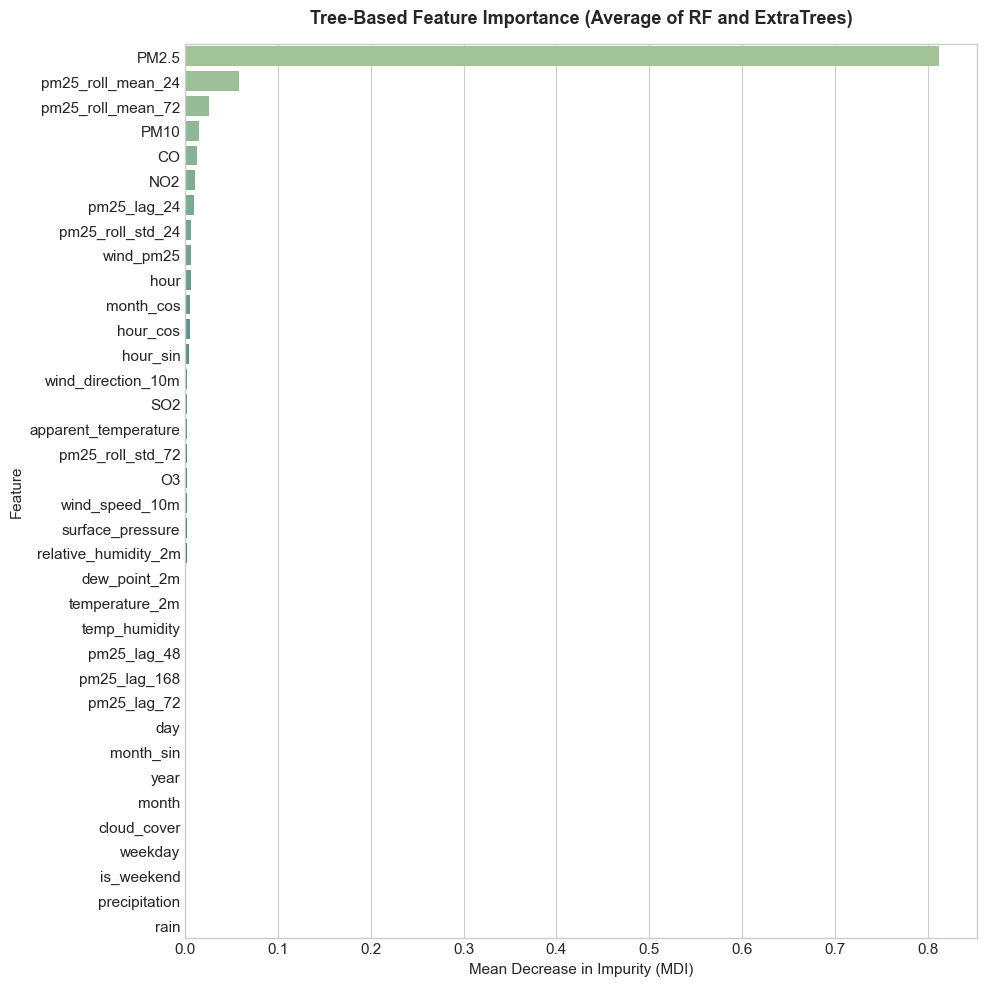

In [16]:
plt.figure(figsize=(10, 10))
sns.barplot(
    data=tree_importance_df,
    y="Feature",
    x="Avg_Tree_Importance",
    palette="crest"
)
plt.title("Tree-Based Feature Importance (Average of RF and ExtraTrees)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Mean Decrease in Impurity (MDI)", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.tight_layout()
plt.show()

## 11. Bivariate Regression Trends with `target_pm25`
Scatter plots with linear regression lines illustrating relationship dynamics between top correlated features and next-hour PM2.5.

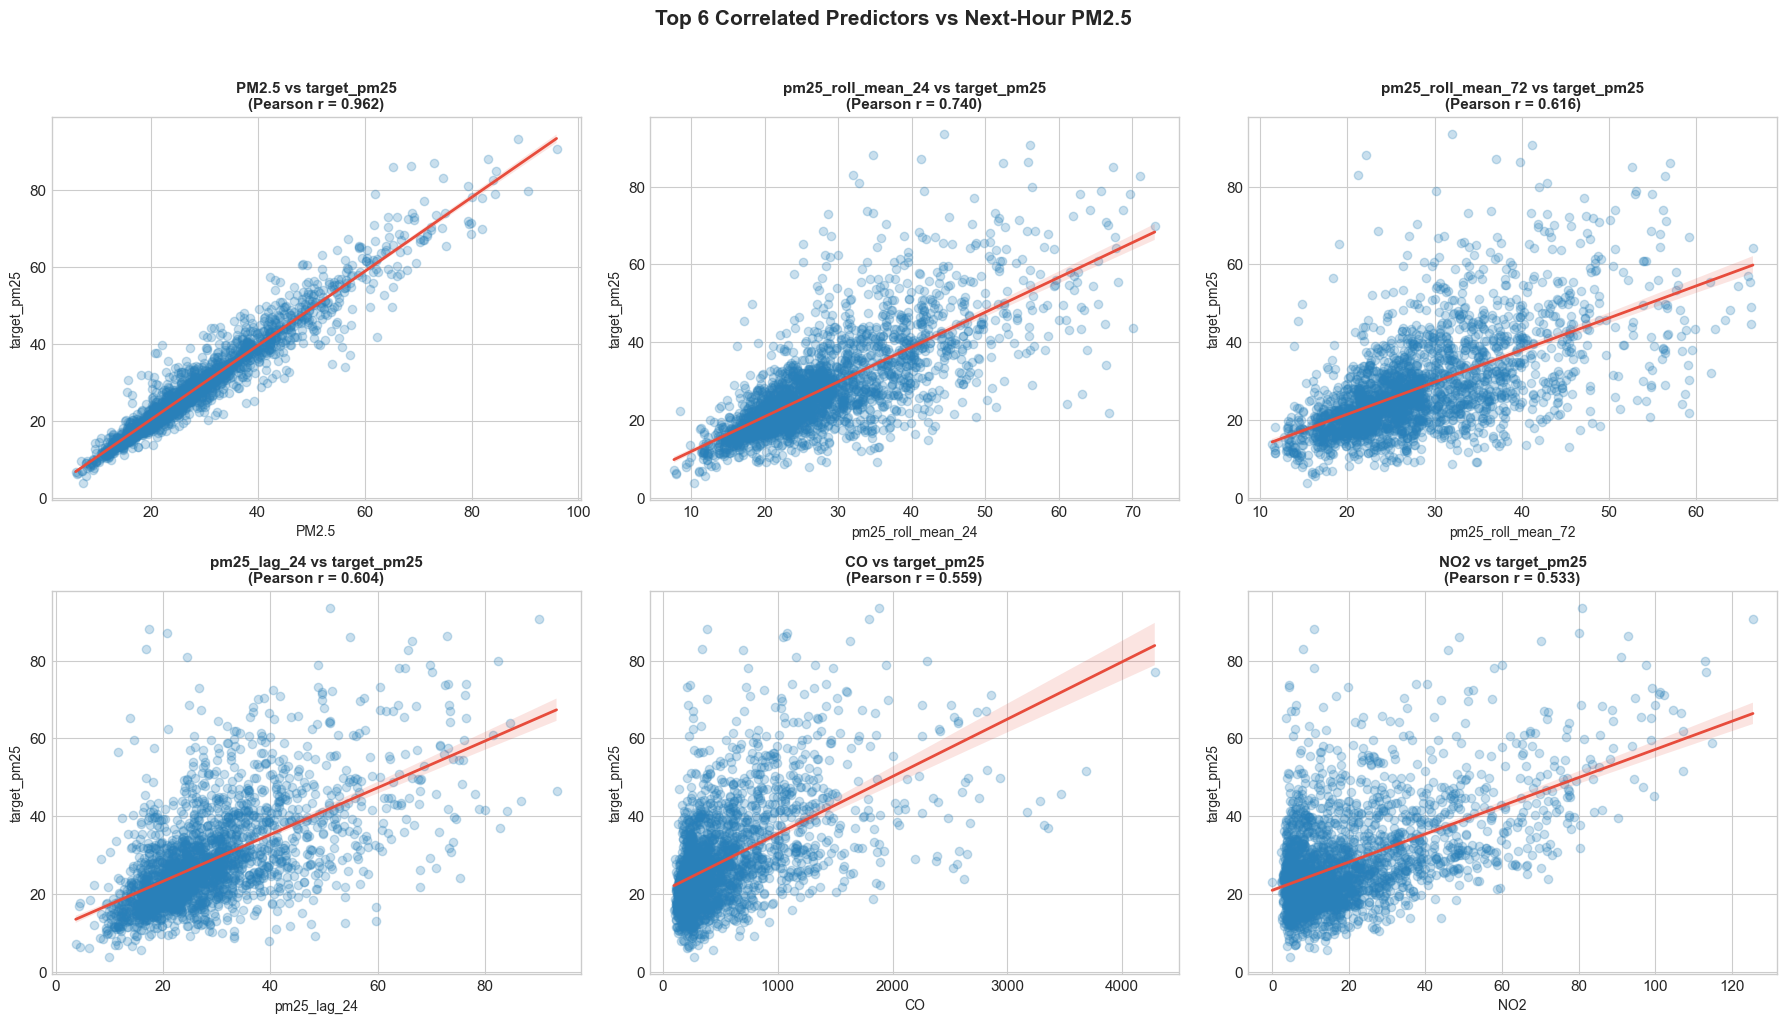

In [17]:
sample_size = min(2500, len(df_indexed))
sample_df = df_indexed.sample(n=sample_size, random_state=42)

top_features = pearson_df["Feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    ax = axes[i]
    r_val = pearson_series[feature]
    sns.regplot(
        data=sample_df,
        x=feature,
        y=TARGET,
        ax=ax,
        scatter_kws={"alpha": 0.25, "color": "#2980b9"},
        line_kws={"color": "#e74c3c", "linewidth": 2}
    )
    ax.set_title(f"{feature} vs {TARGET}\n(Pearson r = {r_val:.3f})", fontsize=11, fontweight="bold")
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel(TARGET, fontsize=10)

plt.suptitle("Top 6 Correlated Predictors vs Next-Hour PM2.5", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 12. Master Feature Selection Summary & Composite Ranking
We combine:
- **Pearson Linear Correlation** ($r$)
- **Spearman Monotonic Correlation** ($
ho$)
- **Mutual Information** (MI)
- **Tree-Based Importance** (MDI)
- **VIF Collinearity Diagnostics**

into a standardized composite score to rank all candidate features.

In [18]:
# Master consolidation
master_df = pearson_df.merge(spearman_df[["Feature", "Spearman_rho", "Abs_Spearman_rho"]], on="Feature") \
                      .merge(mi_df, on="Feature") \
                      .merge(tree_importance_df[["Feature", "Avg_Tree_Importance"]], on="Feature") \
                      .merge(vif_df, on="Feature")

# Min-max normalization for composite scoring
master_df["Norm_Pearson"] = master_df["Abs_Pearson_r"] / master_df["Abs_Pearson_r"].max()
master_df["Norm_Spearman"] = master_df["Abs_Spearman_rho"] / master_df["Abs_Spearman_rho"].max()
master_df["Norm_MI"] = master_df["MI_Score"] / master_df["MI_Score"].max()
master_df["Norm_Tree"] = master_df["Avg_Tree_Importance"] / master_df["Avg_Tree_Importance"].max()

# Weighted Composite Score
master_df["Composite_Score"] = (
    0.30 * master_df["Norm_Pearson"] +
    0.20 * master_df["Norm_Spearman"] +
    0.25 * master_df["Norm_MI"] +
    0.25 * master_df["Norm_Tree"]
)

master_df = master_df.sort_values(by="Composite_Score", ascending=False).reset_index(drop=True)
master_df["Overall_Rank"] = master_df.index + 1

print("=== MASTER FEATURE SELECTION RANKING TABLE ===")
display(master_df[[
    "Overall_Rank", "Feature", "Pearson_r", "Spearman_rho", 
    "MI_Score", "Avg_Tree_Importance", "VIF", "Composite_Score"
]])

=== MASTER FEATURE SELECTION RANKING TABLE ===


,Overall_Rank,Feature,Pearson_r,Spearman_rho,MI_Score,Avg_Tree_Importance,VIF,Composite_Score
0,1,PM2.5,0.961836,0.963624,1.510506,0.812529,12.53,1.000000
1,2,pm25_roll_mean_24,0.739707,0.748068,0.487733,0.057441,10.17,0.484375
2,3,pm25_roll_mean_72,0.615995,0.625357,0.335004,0.025515,13.28,0.385220
3,4,pm25_lag_24,0.604368,0.627397,0.286121,0.009158,3.10,0.368894
4,5,PM10,0.510889,0.591809,0.428384,0.014888,3.38,0.357659
5,6,CO,0.558938,0.529941,0.200689,0.012982,3.79,0.321534
6,7,pm25_roll_std_24,0.509914,0.516340,0.238759,0.006678,3.21,0.307781
7,8,pm25_roll_std_72,0.487928,0.461631,0.265250,0.001914,3.97,0.292488
8,9,SO2,0.495768,0.501535,0.192552,0.001970,3.78,0.291200
9,10,NO2,0.533199,0.394298,0.149461,0.010380,8.61,0.276074


## 13. Recommended Selected Feature Set
### Final Selected Feature Subset for Production Modeling
Based on the composite ranking and collinearity evaluation, we select the top features covering:
1. **Autoregressive & Lag Features**: `PM2.5`, `pm25_roll_mean_24`, `pm25_lag_24`, `pm25_roll_std_24`, `pm25_lag_48`, `pm25_roll_mean_72`
2. **Co-Pollutants**: `CO`, `NO2`, `PM10`, `SO2`
3. **Meteorological Dispersion Dynamics**: `wind_pm25`, `temp_humidity`, `apparent_temperature`, `wind_speed_10m`, `temperature_2m`, `surface_pressure`
4. **Cyclic Temporal Encodings**: `month_cos`, `hour_sin`, `hour_cos`

In [19]:
TOP_K = 18
selected_features = master_df.head(TOP_K)["Feature"].tolist()

print(f"=== TOP {TOP_K} SELECTED FEATURES FOR MODEL TRAINING ===")
for rank, feat in enumerate(selected_features, 1):
    comp = master_df.loc[master_df["Feature"] == feat, "Composite_Score"].values[0]
    p_corr = master_df.loc[master_df["Feature"] == feat, "Pearson_r"].values[0]
    vif = master_df.loc[master_df["Feature"] == feat, "VIF"].values[0]
    print(f"{rank:2d}. {feat:<24} | Composite: {comp:.4f} | Pearson r: {p_corr:+.3f} | VIF: {vif:6.2f}")

# Save selected feature list
output_features_path = Path("../data/processed/selected_features.txt") if Path("../data/processed").exists() else Path("data/processed/selected_features.txt")
with open(output_features_path, "w") as f:
    f.write("\n".join(selected_features))
print(f"\n[OK] Selected feature names saved to: {output_features_path}")

=== TOP 18 SELECTED FEATURES FOR MODEL TRAINING ===
 1. PM2.5                    | Composite: 1.0000 | Pearson r: +0.962 | VIF:  12.53
 2. pm25_roll_mean_24        | Composite: 0.4844 | Pearson r: +0.740 | VIF:  10.17
 3. pm25_roll_mean_72        | Composite: 0.3852 | Pearson r: +0.616 | VIF:  13.28
 4. pm25_lag_24              | Composite: 0.3689 | Pearson r: +0.604 | VIF:   3.10
 5. PM10                     | Composite: 0.3577 | Pearson r: +0.511 | VIF:   3.38
 6. CO                       | Composite: 0.3215 | Pearson r: +0.559 | VIF:   3.79
 7. pm25_roll_std_24         | Composite: 0.3078 | Pearson r: +0.510 | VIF:   3.21
 8. pm25_roll_std_72         | Composite: 0.2925 | Pearson r: +0.488 | VIF:   3.97
 9. SO2                      | Composite: 0.2912 | Pearson r: +0.496 | VIF:   3.78
10. NO2                      | Composite: 0.2761 | Pearson r: +0.533 | VIF:   8.61
11. wind_pm25                | Composite: 0.2702 | Pearson r: +0.482 | VIF:  11.33
12. pm25_lag_48              | Comp